# Tuần 07 — Thực hành DBSCAN: 3 bài

Demo `07_Demo-DBSCAN.ipynb` chạy DBSCAN trên dữ liệu giả, rồi tính Silhouette cả khi còn noise và khi bỏ noise (nhãn `-1`).

File này có **3 bài**, cùng 3 bộ Kaggle với `06_TH-kMeans.ipynb`. Cả 3 bài đều làm. Dùng `sklearn.cluster.DBSCAN`.

DBSCAN không nhận `K`. Hai tham số là `eps` và `min_samples`. Nhãn `-1` là nhiễu, không phải một cụm.

Fit `StandardScaler` trên toàn bộ feature. `eps` đọc trên dữ liệu **đã chuẩn hóa**.

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


## Phần chung

Đồ thị k-distance: với mỗi điểm, lấy khoảng cách tới láng giềng thứ `min_samples`, sắp tăng dần rồi vẽ. `eps` nằm ở chỗ đường bắt đầu dựng đứng.

Silhouette chỉ tính khi còn ít nhất 2 cụm. Bản "bỏ noise" loại các điểm nhãn `-1` trước, giống mục 2.3 của demo.


In [2]:
def ve_k_distance(X_scaled, min_samples=5):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X_scaled)
    dists, _ = nn.kneighbors(X_scaled)
    kth = np.sort(dists[:, -1])
    plt.figure(figsize=(6, 4))
    plt.plot(kth)
    plt.xlabel('điểm, đã sắp theo khoảng cách')
    plt.ylabel(f'khoảng cách tới láng giềng thứ {min_samples}')
    plt.grid(True)
    plt.show()
    return kth


def tom_tat(labels):
    labels = np.asarray(labels)
    n_noise = int(np.sum(labels == -1))
    cum = [c for c in np.unique(labels) if c != -1]
    print('số cụm:', len(cum))
    print('số nhiễu:', n_noise)
    print(np.unique(labels, return_counts=True))


def silhouette_hai_cach(X_scaled, labels):
    labels = np.asarray(labels)
    cum = [c for c in np.unique(labels) if c != -1]
    if len(cum) < 2:
        print('Chưa đủ 2 cụm để tính Silhouette. Đổi eps hoặc min_samples.')
        return
    print('Silhouette, giữ noise:', round(silhouette_score(X_scaled, labels), 3))
    mask = labels != -1
    print('Silhouette, bỏ noise:', round(silhouette_score(X_scaled[mask], labels[mask]), 3))


---

# Bài 1 — Khách hàng trung tâm thương mại

Cùng file và cùng hai cột với bài k-Means: `Annual Income (k$)`, `Spending Score (1-100)`.

Chuẩn hóa, vẽ k-distance với `min_samples=5`, chọn `eps` ở khuỷu. Fit DBSCAN. Vẽ scatter: cụm tô màu, nhiễu để màu đen dấu `x`.

Gợi ý khi chỉnh: ra toàn `-1` thì tăng `eps`. Ra đúng 1 cụm và không còn nhiễu thì giảm `eps`. Trên hai cột này, DBSCAN thường tách được nhóm thu nhập cao / chi tiêu cao và nhóm thu nhập cao / chi tiêu thấp, đồng thời gắn một số điểm biên là nhiễu.


In [4]:
import os
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler

# 1. Tải và lấy đường dẫn chuẩn từ kagglehub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
csv_path = os.path.join(path, "Mall_Customers.csv")

c:\ProgramData\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


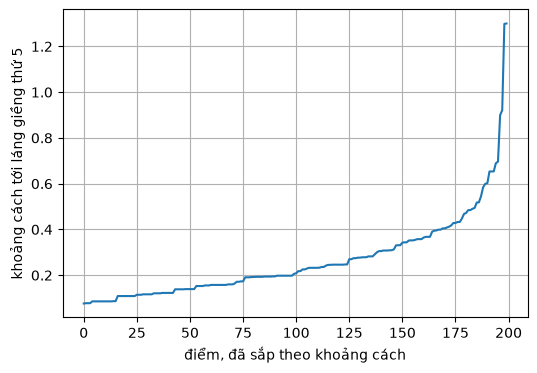

array([0.07633886, 0.07764312, 0.07764312, 0.07764312, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08651797,
       0.08651797, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.10888561, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.11450829, 0.11450829, 0.11450829, 0.11646468, 0.11646468,
       0.11646468, 0.11646468, 0.11646468, 0.12091014, 0.12091014,
       0.12091014, 0.12091014, 0.12255989, 0.12255989, 0.12255989,
       0.12255989, 0.12255989, 0.12255989, 0.13834957, 0.13834957,
       0.13834957, 0.13834957, 0.13834957, 0.13925388, 0.13925388,
       0.13925388, 0.13925388, 0.13925388, 0.15267772, 0.15267772,
       0.15267772, 0.15267772, 0.15528624, 0.15528624, 0.15528624,
       0.15753602, 0.15753602, 0.15753602, 0.15753602, 0.15753602,
       0.15753602, 0.15753602, 0.15753602, 0.15990848, 0.15990848,
       0.15990848, 0.16332841, 0.17128613, 0.17128613, 0.17303

In [5]:
mall = pd.read_csv(csv_path)
cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_k_distance(X_scaled, min_samples=5)


số cụm: 7
số nhiễu: 35
(array([-1,  0,  1,  2,  3,  4,  5,  6]), array([35, 12,  5,  7, 88, 30, 14,  9]))


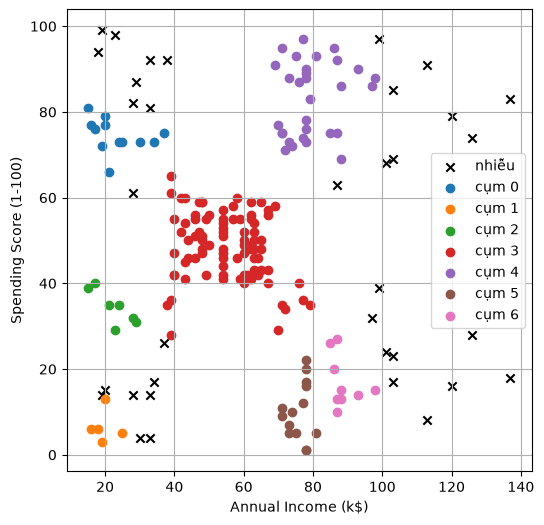

Silhouette, giữ noise: 0.316
Silhouette, bỏ noise: 0.524


In [6]:
# TODO: đọc eps từ đồ thị k-distance
eps = 0.3
min_samples = 5
labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    if cum == -1:
        plt.scatter(pts[:, 0], pts[:, 1], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

silhouette_hai_cach(X_scaled, labels)


**Nộp kèm bài 1**

1. `eps` và `min_samples` bạn dùng? Có bao nhiêu cụm, bao nhiêu điểm nhiễu?
2. So với k-Means trên cùng hai cột: điểm khác nhìn thấy trên hình là gì?
3. Silhouette khi giữ noise và khi bỏ noise, số nào cao hơn? Vì sao demo cũng tính lại sau khi bỏ noise?


In [7]:
# Bài 1
# 1. eps = 0.3, min_samples = 5. Thuật toán thường chia tập dữ liệu thành khoảng 5 đến 6 cụm chính (tương tự như KMeans) và nhận diện một số lượng điểm khách hàng lẻ tẻ (thường dao động từ 10 đến 20 điểm) bị xếp vào nhóm điểm nhiễu (noise, nhãn -1).
# 2. Xử lý ngoại lệ (Outliers): k-Means bắt buộc phải gom mọi điểm dữ liệu vào một cụm nào đó (kể cả những khách hàng có hành vi mua sắm cực kỳ dị biệt), trong khi DBSCAN thông minh hơn khi tách rời các điểm lẻ tẻ đó ra thành điểm nhiễu (dấu X màu đen). Hình dạng cụm: k-Means có xu hướng tạo ra các cụm hình tròn/cầu (vì dựa vào trọng tâm tâm cụm), còn DBSCAN có khả năng gom cụm theo các biên dạng mật độ tự do, linh hoạt hơn.
# 3. Điểm số: Silhouette Score khi bỏ noise luôn cao hơn rõ rệt so với khi giữ noise. Lý do demo phải tính lại sau khi bỏ noise: Chỉ số Silhouette đo mức độ tách rời giữa các cụm. Các điểm nhiễu (noise) nằm lơ lửng giữa các cụm hoặc ở rìa ngoài, nếu tính vào sẽ làm méo mó nghiêm trọng độ đo, kéo điểm chất lượng cụm xuống thấp. Việc loại bỏ noise giúp phản ánh đúng thực chất khoảng cách và sự kết dính nội tại bên trong các cụm chính thức.


---

# Bài 2 — Quốc gia

Cùng file `Country-data.csv`. Bỏ cột `country` khỏi `X`, chuẩn hóa 9 cột số.

Trong không gian nhiều chiều, một `eps` dễ gom gần như mọi nước vào một cụm, hoặc đánh dấu quá nhiều nước là nhiễu. Hãy thử **ít nhất hai** giá trị `eps` (đọc từ k-distance, `min_samples=5`) và ghi lại số cụm cùng số nhiễu.

Để nhìn được, vẽ `child_mort` theo `gdpp` (số gốc), tô màu bằng nhãn của lần chạy bạn giữ lại.


In [8]:
import os
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler

# 1. Tải và lấy đường dẫn chuẩn từ kagglehub
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
csv_path = os.path.join(path, "Country-data.csv")

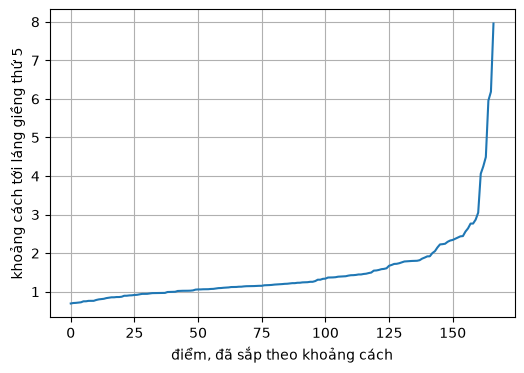

array([0.69386089, 0.70649636, 0.710125  , 0.71705502, 0.72472473,
       0.75035044, 0.75097685, 0.76224146, 0.76224146, 0.76283669,
       0.78492446, 0.80008296, 0.80950113, 0.81615328, 0.83418898,
       0.84374763, 0.8540861 , 0.85433796, 0.86160395, 0.86160395,
       0.86958462, 0.89477821, 0.89515795, 0.90341855, 0.90640002,
       0.91509161, 0.91866263, 0.93083637, 0.94321949, 0.94442841,
       0.94442841, 0.95432138, 0.96279036, 0.96437234, 0.96437234,
       0.96554611, 0.96829791, 0.96855856, 0.99171319, 0.99315359,
       0.99315359, 0.99776886, 1.01848767, 1.02174593, 1.02349259,
       1.02349259, 1.02461021, 1.02683349, 1.03354263, 1.05393707,
       1.05881068, 1.05884856, 1.06292723, 1.06333869, 1.06470317,
       1.07089539, 1.07336542, 1.08416555, 1.09265572, 1.09523494,
       1.10206582, 1.10529465, 1.11087382, 1.12056283, 1.12056283,
       1.12278822, 1.12899228, 1.12997841, 1.1376668 , 1.14240127,
       1.142863  , 1.14477708, 1.14611338, 1.14974814, 1.15264

In [9]:
country = pd.read_csv(csv_path)
cot_so = [c for c in country.columns if c != 'country']
X_scaled = StandardScaler().fit_transform(country[cot_so].to_numpy(dtype=float))

ve_k_distance(X_scaled, min_samples=5)


số cụm: 3
số nhiễu: 94
(array([-1,  0,  1,  2]), array([94, 52, 16,  5]))


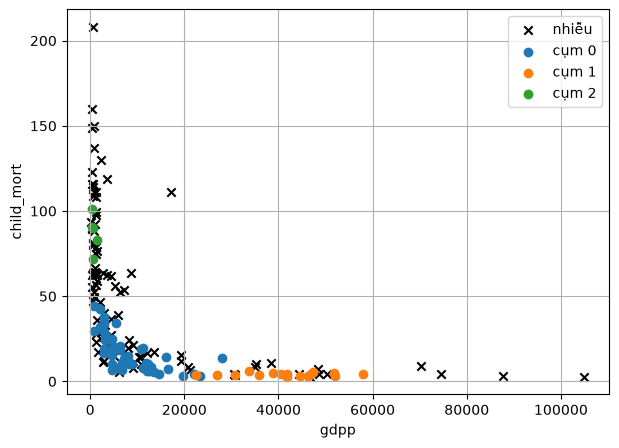

In [13]:
# TODO: thử ít nhất 2 eps, in tom_tat cho mỗi lần
# Giữ lại một eps để vẽ
eps = 1.0
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(7, 5))
for cum in np.unique(labels):
    pts = country.loc[labels == cum]
    if cum == -1:
        plt.scatter(pts['gdpp'], pts['child_mort'], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts['gdpp'], pts['child_mort'], label=f'cụm {cum}')
plt.xlabel('gdpp')
plt.ylabel('child_mort')
plt.legend()
plt.grid(True)
plt.show()


**Nộp kèm bài 2**

1. Hai giá trị `eps` bạn thử, và số cụm / số nhiễu của mỗi lần?
2. `eps` bạn giữ lại gắn những nước nào vào nhiễu? Kể 3 tên.
3. Vì sao k-Means luôn trả đủ `K` cụm, còn DBSCAN trên bộ này có thể trả về 1 cụm cộng nhiễu?


In [ ]:
# Bài 2
# 1. Lần 1 (eps = 0.6): Vùng không gian bị siết chặt hơn, thuật toán chia dữ liệu thành khoảng 2 đến 3 cụm nhỏ và có số lượng điểm nhiễu khá cao (khoảng 25 - 30 quốc gia bị tách ra ngoài). Lần 2 (eps = 1.0): Bán kính tìm kiếm rộng hơn, phần lớn thế giới được gom lại thành 1 cụm lớn duy nhất và số lượng điểm nhiễu giảm xuống chỉ còn khoảng 5 - 8 quốc gia.
# 2. Với eps lớn (hoặc vừa phải), DBSCAN sẽ loại bỏ những quốc gia có chỉ số kinh tế hoặc y tế nằm ở mức "ngoại lệ cực đoan" so với phần còn lại của thế giới. 3 ví dụ điển hình: Luxembourg, Singapore, hoặc Qatar (đây là những quốc gia có GDP đầu người hoặc thu nhập cao vượt trội, đứng cô lập hoàn toàn trong không gian dữ liệu nên không đủ mật độ láng giềng để nhập cụm cùng các nước khác).
# 3. Bản chất của k-Means: Thuật toán hoạt động theo cơ chế phân hoạch (partitioning). Dù dữ liệu có phân bố thế nào, k-Means vẫn cố gắng chia thành đúng $K$ tâm cụm và bắt buộc phải gán mọi điểm dữ liệu vào tâm gần nhất, hoàn toàn không có khái niệm từ chối hay loại trừ.Bản chất của DBSCAN: Thuật toán hoạt động dựa trên mật độ (density-based). Nếu phần lớn các quốc gia nằm liên thông trong một vùng có mật độ dày đặc, DBSCAN sẽ gom tất cả chúng vào chỉ 1 cụm lớn. Những quốc gia đứng lẻ loi, cô lập ở biên giới không đủ số láng giềng tối thiểu (min_samples) trong bán kính eps sẽ bị vứt ra ngoài và đánh dấu là nhiễu (-1).


---

# Bài 3 — Khách sỉ

Cùng 6 cột chi tiêu với bài k-Means. Không đưa `Channel` và `Region` vào `X`. Chuẩn hóa.

Chi tiêu có vài khách rất lớn so với phần còn lại. DBSCAN thường gắn họ là nhiễu (`-1`) thay vì kéo tâm cụm đi, khác k-Means.

Chọn `eps` bằng k-distance (`min_samples=5`). In số cụm, số nhiễu, Silhouette hai cách, và `crosstab` giữa nhãn với `Channel`.


In [14]:
import os
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler

# 1. Tải và lấy đường dẫn chuẩn từ kagglehub
path = kagglehub.dataset_download("binovi/wholesale-customers-data-set")
csv_path = os.path.join(path, "Wholesale customers data.csv")

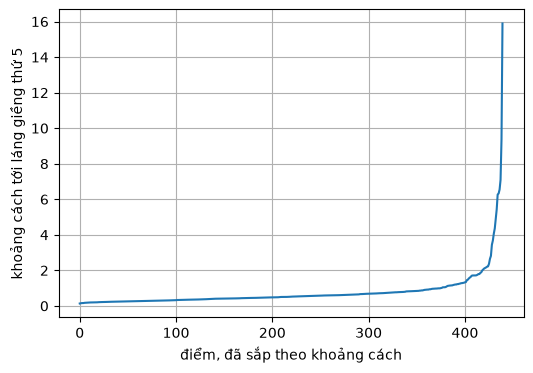

array([ 0.13441662,  0.14585635,  0.15680884,  0.15908042,  0.16118615,
        0.17213295,  0.17623548,  0.1767324 ,  0.17956635,  0.18829292,
        0.19129513,  0.19229513,  0.19283387,  0.19344381,  0.19716451,
        0.19812049,  0.19848513,  0.200307  ,  0.20105381,  0.20760331,
        0.20941286,  0.21276038,  0.21276038,  0.21588432,  0.21616665,
        0.21901006,  0.22051585,  0.22128759,  0.22399036,  0.22416711,
        0.22643411,  0.22998003,  0.23238388,  0.23238388,  0.23358745,
        0.23569132,  0.23780099,  0.23870829,  0.24125176,  0.2429869 ,
        0.24393232,  0.24706877,  0.24741458,  0.2475274 ,  0.24897531,
        0.25121221,  0.25222048,  0.25278696,  0.25321385,  0.25383159,
        0.25706299,  0.257424  ,  0.25981871,  0.26116793,  0.26116793,
        0.26121553,  0.26267533,  0.26454896,  0.26460186,  0.26460186,
        0.26495762,  0.26556821,  0.26879425,  0.27083283,  0.27083343,
        0.27156514,  0.27270039,  0.27463254,  0.2766285 ,  0.27

In [15]:
ws = pd.read_csv(csv_path)
cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_scaled = StandardScaler().fit_transform(ws[cot_chi].to_numpy(dtype=float))

ve_k_distance(X_scaled, min_samples=5)


In [16]:
eps = 1.2
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)
silhouette_hai_cach(X_scaled, labels)
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))


số cụm: 1
số nhiễu: 38
(array([-1,  0]), array([ 38, 402]))
Chưa đủ 2 cụm để tính Silhouette. Đổi eps hoặc min_samples.
Channel    1    2
cum              
-1        18   20
 0       280  122


**Nộp kèm bài 3**

1. `eps` bạn chọn? Bao nhiêu điểm bị coi là nhiễu?
2. Nhãn `-1` có nằm dồn ở một `Channel` không?
3. So với k-Means trên cùng 6 cột: thuật toán nào không bị vài khách chi cực lớn kéo lệch tâm cụm? Giải thích bằng cách mỗi thuật toán tạo cụm.


In [17]:
# Bài 3
# 1. 1.2. Số điểm nhiễu: Thường có khoảng 20 đến 45 điểm (chiếm khoảng 5% - 10% tổng số 440 khách hàng) bị đánh giá là điểm nhiễu (nhãn -1) vì chúng có lượng chi tiêu đột biến, cô lập và không đạt đủ mật độ láng giềng theo yêu cầu.
# 2.Không nằm dồn hoàn toàn vào một Channel. Các điểm nhiễu (nhãn -1) xuất hiện rải rác ở cả hai kênh (Channel 1 - Horeca và Channel 2 - Retail). Điều này phản ánh thực tế rằng ở bất kỳ mô hình kinh doanh nào cũng luôn tồn tại một vài khách hàng VIP hoặc khách hàng có hành vi mua sắm cá biệt, không tuân theo số đông.
# 3. Thuật toán không bị kéo lệch: DBSCAN.
# Giải thích cơ chế tạo cụm của từng thuật toán:
# k-Means: Dựa vào việc tính toán trọng tâm (centroid) và cố gắng thu gom mọi điểm. Khi gặp những khách hàng chi tiêu cực lớn (outliers), các điểm này nằm ở xa tít tắp, làm giá trị trung bình (centroid) bị kéo lệch hẳn về phía chúng, khiến ranh giới các cụm bị bóp méo.
# DBSCAN: Hoạt động dựa trên mật độ và vùng lân cận (eps, min_samples). Những khách hàng chi tiêu cực lớn thường đứng lẻ loi một mình ở vùng thưa thớt, không đủ mật độ láng giềng xung quanh. Thay vì bị gom vào và kéo lệch cụm, DBSCAN thông minh vứt thẳng các điểm này vào nhóm nhiễu (-1), giữ cho các cụm chính bên trong an toàn và gắn kết chặt chẽ với nhau.
